# $(SASA) Models - Kmodels$

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [15]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
561,10,20,"(0.4182227977310492, 0.0863390757150445)","(-0.026, 0.578, -0.045, -4.817)",0,1.0,"(-0.015, 0.3, -0.141, -2.706)",0.0,1.0,"(-0.009, 0.034, -0.195, -0.856)"
2388,11,94,"(0.4377652476268179, 0.9729568415243506)","(-0.039, -0.165, 0.039, 0.226)",0,1.0,"(-0.042, -0.357, 0.043, 0.434)",0.0,1.0,"(-0.049, -0.548, 0.052, 0.643)"
1289,11,53,"(0.2444473003074412, 0.4846825463128728)","(-0.08, 0.215, 0.055, -0.215)",1,1.0,"(-0.075, 0.412, 0.051, -0.532)",0.0,1.0,"(-0.067, 0.214, 0.04, -0.177)"
287,3,10,"(0.0746887501825485, 0.1350490291932765)","(0.058, 0.197, -0.031, -1.011)",1,1.0,"(0.061, 0.429, -0.051, -2.11)",0.0,1.0,"(0.07, 0.201, -0.093, -1.105)"
508,60,19,"(0.0642916329828742, 1.239005358213764)","(0.05, 0.023, 0.089, 0.384)",1,1.0,"(0.051, 0.21, 0.097, 0.28)",1.0,1.0,"(0.055, 0.396, 0.103, 0.178)"
...,...,...,...,...,...,...,...,...,...,...
753,27,26,"(0.2353791242085411, 0.7095048192803978)","(-0.18, -0.991, 0.149, 1.258)",1,1.0,"(-0.2, -0.801, 0.174, 1.069)",1.0,1.0,"(-0.216, -0.611, 0.195, 0.887)"
60,2,3,"(0.1246662838321873, 0.2504382527828622)","(-0.038, -0.028, 0.019, 0.047)",0,1.0,"(-0.039, -0.237, 0.02, 0.654)",1.0,1.0,"(-0.044, -0.029, 0.033, 0.072)"
256,8,9,"(0.0614156820293939, 0.6127438843111195)","(0.003, -0.024, 0.054, 0.077)",1,1.0,"(0.002, 0.168, 0.056, -0.142)",1.0,1.0,"(0.006, 0.36, 0.053, -0.359)"
2315,2,92,"(0.1771043759930183, 0.8300521931250568)","(0.005, -0.042, -0.012, -0.023)",1,1.0,"(0.004, 0.148, -0.012, -0.212)",0.0,1.0,"(0.007, -0.042, -0.017, -0.028)"


In [16]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1223,16,50,"(0.3156324259991037, 0.4950654122165437)","(0.088, 0.438, -0.082, -0.85)",1,1.0,"(0.096, 0.637, -0.099, -1.23)",0.0,1.0,"(0.109, 0.441, -0.123, -0.918)",0.088,0.438,-0.082,-0.850,0.096,0.637,-0.099,-1.230,0.315632,0.495065
1333,2,55,"(0.8034667051045895, 0.8611481301108855)","(0.039, 0.038, -0.036, -0.048)",0,1.0,"(0.039, -0.159, -0.037, 0.287)",0.0,1.0,"(0.036, -0.356, -0.032, 0.622)",0.039,0.038,-0.036,-0.048,0.039,-0.159,-0.037,0.287,0.803467,0.861148
1964,12,78,"(0.0956613712139894, 0.231794730405182)","(0.01, 0.045, -0.018, -0.044)",1,1.0,"(0.011, 0.256, -0.019, -0.686)",0.0,1.0,"(0.016, 0.046, -0.033, -0.07)",0.010,0.045,-0.018,-0.044,0.011,0.256,-0.019,-0.686,0.095661,0.231795
1606,28,65,"(0.1785778102029531, 1.438381745613701)","(0.076, 0.756, -0.124, -0.623)",0,1.0,"(0.092, 0.57, -0.136, -0.53)",1.0,1.0,"(0.103, 0.757, -0.147, -0.653)",0.076,0.756,-0.124,-0.623,0.092,0.570,-0.136,-0.530,0.178578,1.438382
467,19,19,"(0.0642916329828742, 1.239005358213764)","(-0.153, -0.146, 0.058, 0.097)",0,1.0,"(-0.155, -0.333, 0.06, 0.219)",1.0,1.0,"(-0.162, -0.146, 0.064, 0.112)",-0.153,-0.146,0.058,0.097,-0.155,-0.333,0.060,0.219,0.064292,1.239005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,23,31,"(0.202531051367323, 0.357238297754249)","(-0.003, -0.267, 0.124, 0.919)",1,1.0,"(-0.008, -0.068, 0.143, 0.54)",0.0,1.0,"(-0.009, -0.272, 0.154, 1.044)",-0.003,-0.267,0.124,0.919,-0.008,-0.068,0.143,0.540,0.202531,0.357238
596,24,22,"(0.1859246409325834, 0.509421113235871)","(-0.122, -0.78, -0.032, 0.51)",1,1.0,"(-0.138, -0.584, -0.022, 0.193)",0.0,1.0,"(-0.15, -0.779, -0.018, 0.492)",-0.122,-0.780,-0.032,0.510,-0.138,-0.584,-0.022,0.193,0.185925,0.509421
1780,54,69,"(0.1433033517266329, 1.8075969481187537)","(0.787, 3.333, -0.132, -1.255)",0,1.0,"(0.854, 3.148, -0.157, -1.184)",1.0,1.0,"(0.917, 3.334, -0.18, -1.28)",0.787,3.333,-0.132,-1.255,0.854,3.148,-0.157,-1.184,0.143303,1.807597
111,23,5,"(0.3551867425587211, 0.959194989729514)","(-0.066, -0.544, 0.099, 0.618)",0,1.0,"(-0.077, -0.735, 0.111, 0.823)",0.0,1.0,"(-0.091, -0.926, 0.128, 1.031)",-0.066,-0.544,0.099,0.618,-0.077,-0.735,0.111,0.823,0.355187,0.959195


# Initialization by Random Partitioning

In [17]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]
params = [1/k for _ in range(k)]

In [18]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
1223,16,50,"(0.3156324259991037, 0.4950654122165437)","(0.088, 0.438, -0.082, -0.85)",1,1.0,"(0.096, 0.637, -0.099, -1.23)",0.0,1.0,"(0.109, 0.441, -0.123, -0.918)",...,0.438,-0.082,-0.850,0.096,0.637,-0.099,-1.230,0.315632,0.495065,3.0
1333,2,55,"(0.8034667051045895, 0.8611481301108855)","(0.039, 0.038, -0.036, -0.048)",0,1.0,"(0.039, -0.159, -0.037, 0.287)",0.0,1.0,"(0.036, -0.356, -0.032, 0.622)",...,0.038,-0.036,-0.048,0.039,-0.159,-0.037,0.287,0.803467,0.861148,2.0
1964,12,78,"(0.0956613712139894, 0.231794730405182)","(0.01, 0.045, -0.018, -0.044)",1,1.0,"(0.011, 0.256, -0.019, -0.686)",0.0,1.0,"(0.016, 0.046, -0.033, -0.07)",...,0.045,-0.018,-0.044,0.011,0.256,-0.019,-0.686,0.095661,0.231795,1.0
1606,28,65,"(0.1785778102029531, 1.438381745613701)","(0.076, 0.756, -0.124, -0.623)",0,1.0,"(0.092, 0.57, -0.136, -0.53)",1.0,1.0,"(0.103, 0.757, -0.147, -0.653)",...,0.756,-0.124,-0.623,0.092,0.570,-0.136,-0.530,0.178578,1.438382,0.0
467,19,19,"(0.0642916329828742, 1.239005358213764)","(-0.153, -0.146, 0.058, 0.097)",0,1.0,"(-0.155, -0.333, 0.06, 0.219)",1.0,1.0,"(-0.162, -0.146, 0.064, 0.112)",...,-0.146,0.058,0.097,-0.155,-0.333,0.060,0.219,0.064292,1.239005,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,23,31,"(0.202531051367323, 0.357238297754249)","(-0.003, -0.267, 0.124, 0.919)",1,1.0,"(-0.008, -0.068, 0.143, 0.54)",0.0,1.0,"(-0.009, -0.272, 0.154, 1.044)",...,-0.267,0.124,0.919,-0.008,-0.068,0.143,0.540,0.202531,0.357238,0.0
596,24,22,"(0.1859246409325834, 0.509421113235871)","(-0.122, -0.78, -0.032, 0.51)",1,1.0,"(-0.138, -0.584, -0.022, 0.193)",0.0,1.0,"(-0.15, -0.779, -0.018, 0.492)",...,-0.780,-0.032,0.510,-0.138,-0.584,-0.022,0.193,0.185925,0.509421,1.0
1780,54,69,"(0.1433033517266329, 1.8075969481187537)","(0.787, 3.333, -0.132, -1.255)",0,1.0,"(0.854, 3.148, -0.157, -1.184)",1.0,1.0,"(0.917, 3.334, -0.18, -1.28)",...,3.333,-0.132,-1.255,0.854,3.148,-0.157,-1.184,0.143303,1.807597,3.0
111,23,5,"(0.3551867425587211, 0.959194989729514)","(-0.066, -0.544, 0.099, 0.618)",0,1.0,"(-0.077, -0.735, 0.111, 0.823)",0.0,1.0,"(-0.091, -0.926, 0.128, 1.031)",...,-0.544,0.099,0.618,-0.077,-0.735,0.111,0.823,0.355187,0.959195,4.0


## Initial Training 

In [19]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        if group_data.shape[0] > 0:
            x, y = model.get_features_targets(group_data)
            trainer = model.train(x, y, num_epochs=1000)
            train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [20]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.10901831835508347, 0.45341917872428894, 0.0...",1.642638,0.319862
1,1,"[0.10790450870990753, 0.45034414529800415, 0.0...",1.629505,0.318332
2,2,"[0.10681186616420746, 0.447285532951355, 0.087...",1.616490,0.316819
3,3,"[0.10573820769786835, 0.44423598051071167, 0.0...",1.603592,0.315333
4,4,"[0.1046798825263977, 0.4411833882331848, 0.082...",1.590810,0.313882


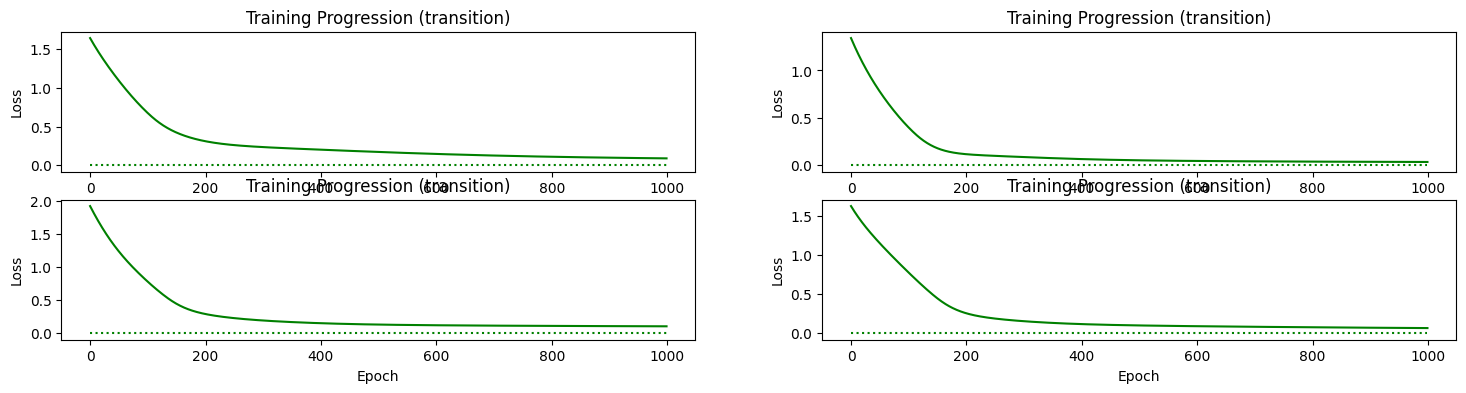

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [22]:
def get_model_metrics(prediction_dataset, results, i):
    prediction_dataset[f'rse_model_{i}'] = results['rse']
    prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

    prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
    prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
    prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
    prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

    prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
    prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
    prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
    prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']

def get_weighed_model_metrics(prediction_dataset, results, i):
    prediction_dataset[f'rse_weighed_model_{i}'] = results['rse']
    prediction_dataset[f'rse_weighed_normalized_model_{i}'] = results['rse_normalized']

    prediction_dataset[f'rse_s0_weighed_model_{i}'] = results['rse_s0']
    prediction_dataset[f'rse_s1_weighed_model_{i}'] = results['rse_s1']
    prediction_dataset[f'rse_s2_weighed_model_{i}'] = results['rse_s2']
    prediction_dataset[f'rse_s3_weighed_model_{i}'] = results['rse_s3']

    prediction_dataset[f'rse_s0_weighed_normalized_model_{i}'] = results['rse_s0_normalized']
    prediction_dataset[f'rse_s1_weighed_normalized_model_{i}'] = results['rse_s1_normalized']
    prediction_dataset[f'rse_s2_weighed_normalized_model_{i}'] = results['rse_s2_normalized']
    prediction_dataset[f'rse_s3_weighed_normalized_model_{i}'] = results['rse_s3_normalized']

def evaluate(models, params, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        prediction_dataset[f'estimated_s_weighed_model_{i}'] = pred['estimated_s'].apply(lambda x: [n*params[i] for n in x])
        prediction_dataset[f'pram_{i}'] = params[i]

        pred['estimated_s'] = prediction_dataset[f'estimated_s_model_{i}']
        results = data.get_evaluation_metrics(pred, p=False)
        get_model_metrics(prediction_dataset, results, i)

        pred['estimated_s'] = prediction_dataset[f'estimated_s_weighed_model_{i}']
        results = data.get_evaluation_metrics(pred, p=False)
        get_weighed_model_metrics(prediction_dataset, results, i)


    return prediction_dataset

In [23]:
prediction_dataset = evaluate(models, params, df)
prediction_dataset.head()

/tmp/ipykernel_8738/4124108212.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
/tmp/ipykernel_8738/4124108212.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
/tmp/ipykernel_8738/4124108212.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_weighed_model_4,rse_weighed_normalized_model_4,rse_s0_weighed_model_4,rse_s1_weighed_model_4,rse_s2_weighed_model_4,rse_s3_weighed_model_4,rse_s0_weighed_normalized_model_4,rse_s1_weighed_normalized_model_4,rse_s2_weighed_normalized_model_4,rse_s3_weighed_normalized_model_4
1223,16,50,"(0.3156324259991037, 0.4950654122165437)","(0.088, 0.438, -0.082, -0.85)",1,1.0,"(0.096, 0.637, -0.099, -1.23)",0.0,1.0,"(0.109, 0.441, -0.123, -0.918)",...,1.2552,0.568586,0.0896,0.3464,0.0996,0.7196,0.440716,0.479422,0.737650,0.616557
1333,2,55,"(0.8034667051045895, 0.8611481301108855)","(0.039, 0.038, -0.036, -0.048)",0,1.0,"(0.039, -0.159, -0.037, 0.287)",0.0,1.0,"(0.036, -0.356, -0.032, 0.622)",...,0.8294,0.512478,0.0324,0.2780,0.0266,0.4924,0.416903,0.467503,0.562590,0.602918
1964,12,78,"(0.0956613712139894, 0.231794730405182)","(0.01, 0.045, -0.018, -0.044)",1,1.0,"(0.011, 0.256, -0.019, -0.686)",0.0,1.0,"(0.016, 0.046, -0.033, -0.07)",...,0.0870,0.493324,0.0150,0.0312,0.0276,0.0132,0.409659,0.424499,0.564988,0.574151
1606,28,65,"(0.1785778102029531, 1.438381745613701)","(0.076, 0.756, -0.124, -0.623)",0,1.0,"(0.092, 0.57, -0.136, -0.53)",1.0,1.0,"(0.103, 0.757, -0.147, -0.653)",...,1.2666,0.588023,0.0784,0.6016,0.1218,0.4648,0.436053,0.523889,0.790887,0.601261
467,19,19,"(0.0642916329828742, 1.239005358213764)","(-0.153, -0.146, 0.058, 0.097)",0,1.0,"(-0.155, -0.333, 0.06, 0.219)",1.0,1.0,"(-0.162, -0.146, 0.064, 0.112)",...,0.4254,0.523601,0.1332,0.1110,0.0488,0.1324,0.458868,0.438404,0.615827,0.581306


In [ ]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
        f'rse_model_{i}' for i,_ in enumerate(models)
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [25]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
4    39
0    36
3    11
1     8
2     6
Name: count, dtype: int64


/tmp/ipykernel_8738/2697676486.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
/tmp/ipykernel_8738/2697676486.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)


,best_rse
count,2504.000000
mean,0.195786
std,0.221865
min,0.013000
25%,0.090000
50%,0.143000
75%,0.234250
max,4.280000


In [28]:
def reagroup_weighed(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
        f'rse_weighed_model_{i}' for i,_ in enumerate(models)
    ]].groupby('episode').mean().reset_index()

    agg_results['best_weighed_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_weighed_model'].value_counts())

    prediction_dataset['best_weighed_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_weighed_model.values[0],axis=1)
    prediction_dataset['best_weighed_rse'] = prediction_dataset.apply(lambda row: row[f'rse_weighed_model_{row.best_weighed_model}'],axis=1)

    return prediction_dataset


prediction_dataset = reagroup_weighed(prediction_dataset)
prediction_dataset[['best_weighed_rse']].describe()

best_weighed_model
0    54
2    35
3     6
4     4
1     1
Name: count, dtype: int64


,best_weighed_rse
count,2504.000000
mean,1.045624
std,0.874004
min,0.024600
25%,0.452050
50%,0.809000
75%,1.388250
max,9.412400


In [29]:
def optimize_params(prediction_dataset):
    expansions = {f'estimated_s_model_{i}': [f's0_{i}', f's1_{i}', f's2_{i}', f's3_{i}'] for i, _ in enumerate(models)}
    expansions.update({'s__': ['s_0', 's_1', 's_2', 's_3']})
    df = get_data_expanded(prediction_dataset, expansions)
    df['A'] = df.apply(lambda row: np.array([[row[f's{d}_{m}'] for m,_ in enumerate(models)] for d in range(4)]),axis=1)
    df['b'] = df.apply(lambda row: np.array([row[f's_{d}'] for d in range(4)]),axis=1)
    df['w'] = df.apply(lambda row: np.linalg.lstsq(row.A, row.b)[0],axis=1)
    return df.w.to_numpy().mean().tolist()

params = optimize_params(prediction_dataset)
params

[0.5188517032628345,
 -0.13449372047108443,
 0.05116399479350059,
 0.18310542026902835,
 0.33629950456532165]

# LOOP

In [30]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    
    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, params, prediction_dataset)
    prediction_dataset = reagroup(prediction_dataset)
    params = optimize_params(prediction_dataset)

    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1481
best_model
4    33
3    29
0    23
1    10
2     5
Name: count, dtype: int64
best_rse    0.124822
dtype: float64
epis_changed: 1737
best_model
3    35
4    27
1    21
0    11
2     6
Name: count, dtype: int64
best_rse    0.088887
dtype: float64
epis_changed: 1834
best_model
1    32
3    31
4    22
0     9
2     6
Name: count, dtype: int64
best_rse    0.069464
dtype: float64
epis_changed: 1782
best_model
1    34
3    31
4    21
0     8
2     6
Name: count, dtype: int64
best_rse    0.05943
dtype: float64
epis_changed: 1763
best_model
1    35
3    32
4    20
0     7
2     6
Name: count, dtype: int64
best_rse    0.0529
dtype: float64
epis_changed: 1750
best_model
1    35
3    32
4    20
0     7
2     6
Name: count, dtype: int64
best_rse    0.047837
dtype: float64
epis_changed: 1750
best_model
1    34
3    33
4    20
0     7
2     6
Name: count, dtype: int64
best_rse    0.044331
dtype: float64
epis_changed: 1769
best_model
1    35
3    33
4    19
0     7
2     6
Name: cou

In [31]:
params

[0.07894017238279974,
 0.29797472134557285,
 0.013185968776257618,
 0.4088604063129853,
 0.20406278420665652]